# Math Basics in Statistics & Probability

#### 1. beste Schätzung / Erwartungswert: 
$$\hat{x} = \mathbb{E}[x]= \frac{1}{n}\sum_{i=1}^n x_i$$

#### 2. Varianz - wie stark der Wert x um seinen Erwartungswert streut:


$$\mathrm{Var}(x) = \mathbb{E}[(x - \mathbb{E}[x])^2]$$

bei endlichen Datenpunkten:

$$\mathrm{Var}(x) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

Die Varianz sagt dir also:
- Wie unsicher oder gestreut deine Schätzung ist.
- Je größer die Varianz, desto weniger Vertrauen hast du in deine Schätzung.

#### 3. Probability

<a>
  <img src="../../images/probability.png" alt="Pinhole camera" width="500" >
</a>

<a>
  <img src="../../images/calculation rules_discrete variables.png" alt="Pinhole camera" width="500" >
</a>

<a>
  <img src="../../images/stochastic independence.png" alt="Pinhole camera" width="500" >
</a>

<a>
  <img src="../../images/continous variables.png" alt="Pinhole camera" width="500" >
</a>

<a>
  <img src="../../images/calculation rules_continous variables.png" alt="Pinhole camera" width="500" >
</a>

# HIDDEN MARKOV MODELS

### **main idea:**
- a system is described by its system state
- changes in the system over time are completely described by changes of its state

### **example: car with constant velocity** 


- system state or *or hidden state* $s(t)$: 
    - 1D model with position x(t), velocity (vt)
$$s(t)=\begin{bmatrix}
x(t) \\
v(t) \\
\end{bmatrix}$$


- transition:
$$x(t+\Delta)= x(t) + \Delta \cdot v(t) + noise$$
$$v(t+\Delta)= v(t) + noise$$
$$s(t+\Delta)= \begin{bmatrix}
1 & \Delta \\
0 & 1 \\
\end{bmatrix} \cdot s(t) + noise$$

- observation $z(t)$ 
    - States can only be observed. An observation always includes the state and some form of noise. In our example we have a camera observing a car. It would be nice to observe the state s(t) but the velocity is not observable in our case. Thats why we observe only the position up to small random errors. [we only take the first]
    
$$z(t) = x(t) + noise$$

Mathematically an observation is a conditional probability (see above), that depends on the current state s(t):



## Jacobi Matrix

$$
\begin{bmatrix}
\frac{\partial f_1}{x_1} & ... & \frac{\partial f_n}{x_1} \\
... & ... & ... \\
\frac{\partial f_n}{x_1} & ... & \frac{\partial f_n}{x_n}\\
\end{bmatrix}$$

In [ ]:
# Markov Model

import numpy as np

np.random.seed(0)  # für Reproduzierbarkeit

# Anzahl Zeitschritte
T = 20

# Zeitintervall
dt = 1.0

# Initialer Zustand: Position x, Geschwindigkeit v
s = np.array([[0.0],
              [1.0]])

# Zustandsmodell (1D Bewegung)
# A beschreibt die Bewegungsgleichung: $x(t+1) = x(t) + v(t) \cdot dt$
A = np.array([[1, dt],
              [0, 1]])

# Beobachtungsmodell: misst nur Position
H = np.array([[1, 0]])

# Prozessrauschen (Modellunschärfe)
# Q modelliert Unsicherheit im Bewegungsmodell (z. B. wechselnde Geschwindigkeit)
Q = np.array([[0.25, 0.0],
              [0.0, 0.01]])

# Messrauschen (Sensorunschärfe)
R = np.array([[4.0]])

print(" t |  x(t) |  v(t) | noise |  z(t)")
print("-------------------------------------")
for t in range(T):
    # Rauschen generieren
    w = np.random.multivariate_normal([0, 0], Q).reshape(2, 1) # Prozessrauschen
    n = np.random.normal(0, np.sqrt(R[0, 0])) # Messrauschen

    # Neuer Zustand mit Prozessrauschen
    s = A @ s + w

    # Beobachtung (nur Position aber mit Messrauschen)
    z = H @ s + n

    # Werte extrahieren
    x = s[0, 0]
    v = s[1, 0]
    z_val = z.item()

    print(f"{t+1:2d} | {x:6.2f} | {v:6.2f} | {n:6.2f} | {z_val:6.2f}")

 t |  x(t) |  v(t) | noise |  z(t)
-------------------------------------
 1 |   1.88 |   1.04 |   1.96 |   3.84
 2 |   4.04 |   1.23 |  -1.95 |   2.09
 3 |   5.74 |   1.21 |  -0.21 |   5.54
 4 |   7.16 |   1.23 |   2.91 |  10.07
 5 |   8.77 |   1.24 |   0.89 |   9.66
 6 |  10.17 |   1.39 |  -0.41 |   9.76
 7 |  11.72 |   1.30 |  -5.11 |   6.61
 8 |  13.35 |   1.39 |  -1.48 |  11.86
 9 |  15.87 |   1.24 |   0.09 |  15.96
10 |  17.02 |   1.40 |   2.94 |  19.96
11 |  18.49 |   1.43 |  -1.78 |  16.72
12 |  18.94 |   1.40 |   0.31 |  19.25
13 |  20.95 |   1.52 |  -0.77 |  20.18
14 |  22.32 |   1.41 |  -2.84 |  19.48
15 |  22.88 |   1.61 |  -1.02 |  21.86
16 |  24.27 |   1.48 |   1.55 |  25.83
17 |  24.95 |   1.46 |  -1.79 |  23.16
18 |  26.61 |   1.41 |  -2.36 |  24.25
19 |  28.01 |   1.46 |   0.13 |  28.14
20 |  29.61 |   1.39 |  -0.73 |  28.89


Erklärung:
- A beschreibt die Bewegungsgleichung: $x(t+1) = x(t) + v(t) \cdot dt$
- Q modelliert Unsicherheit im Bewegungsmodell (z. B. wechselnde Geschwindigkeit)
- R modelliert Unsicherheit in der Messung (z. B. ungenauer Sensor)
- z(t) ist die gemessene Position mit Rauschen
- x(t) und v(t) sind die tatsächlichen (aber versteckten) Zustände


In [ ]:
# Kalman Filter für die Bewegungsschätzung 

import numpy as np

np.random.seed(0)

# Anzahl Zeitschritte
T = 20
dt = 1.0

# Zustand: x, v
s = np.array([[0.0], [1.0]])

# Zustandsmatrix A (ohne Beschleunigung)
A = np.array([
    [1, dt],
    [0,  1]
])

# Beobachtungsmatrix H (wir messen nur x)
H = np.array([[1, 0]])

# Prozess- und Messrauschen
Q = np.diag([1e-4, 1e-4])
R = np.array([[0.001]])

# Initiale Kovarianz
P = np.eye(2)

# Initialer Schätzwert
s_hat = np.array([[0.0], [0.0]])

print(" t |  x(t)  |  v(t)  |   z(t)  | x̂(t)   | v̂(t)")
print("--------------------------------------------------")

for t in range(T):
    # Prozessrauschen & Messrauschen
    w = np.random.multivariate_normal([0, 0], Q).reshape(2, 1)
    n = np.random.normal(0, np.sqrt(R[0, 0]))

    # Systemdynamik & Beobachtung
    s = A @ s + w  # wahrer Zustand
    z = H @ s + n  # Messung

    # --- KALMAN FILTER ---
    s_hat = A @ s_hat
    P = A @ P @ A.T + Q

    y = z - H @ s_hat
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)

    s_hat = s_hat + K @ y
    P = (np.eye(2) - K @ H) @ P

    print(f"{t+1:2d} | {s[0,0]:6.2f} | {s[1,0]:6.2f} | {z[0,0]:7.2f} "
          f"| {s_hat[0,0]:6.2f} | {s_hat[1,0]:6.2f}")

 t |  x(t)  |  v(t)  |   z(t)  | x̂(t)   | v̂(t)
--------------------------------------------------
 1 |   1.02 |   1.00 |    1.05 |   1.05 |   0.52
 2 |   2.04 |   1.02 |    2.01 |   2.01 |   0.96
 3 |   3.08 |   1.02 |    3.07 |   3.06 |   1.01
 4 |   4.10 |   1.02 |    4.15 |   4.13 |   1.04
 5 |   5.13 |   1.02 |    5.15 |   5.15 |   1.03
 6 |   6.16 |   1.04 |    6.15 |   6.17 |   1.03
 7 |   7.20 |   1.03 |    7.12 |   7.15 |   1.01
 8 |   8.24 |   1.04 |    8.21 |   8.19 |   1.02
 9 |   9.30 |   1.02 |    9.30 |   9.26 |   1.04
10 |  10.32 |   1.04 |   10.37 |  10.34 |   1.05
11 |  11.36 |   1.04 |   11.33 |  11.36 |   1.04
12 |  12.39 |   1.04 |   12.39 |  12.40 |   1.04
13 |  13.44 |   1.05 |   13.43 |  13.43 |   1.04
14 |  14.49 |   1.04 |   14.44 |  14.45 |   1.03
15 |  15.51 |   1.06 |   15.50 |  15.49 |   1.03
16 |  16.57 |   1.05 |   16.59 |  16.56 |   1.05
17 |  17.60 |   1.05 |   17.57 |  17.59 |   1.04
18 |  18.65 |   1.04 |   18.61 |  18.62 |   1.04
19 |  19.69 |   1.

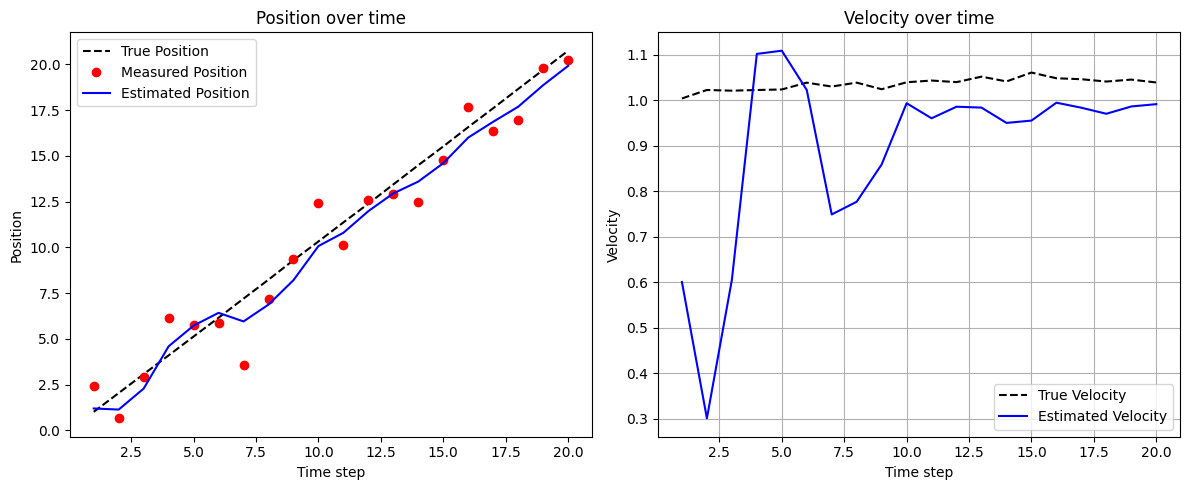

In [ ]:
# Kalman Filter geplottet 

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Parameter
T = 20
dt = 1.0

# Zustand: x (Position), v (Geschwindigkeit)
s = np.array([[0.0], [1.0]])

# Systemmatrix
A = np.array([[1, dt],
              [0, 1]])

# Beobachtungsmatrix (wir messen nur Position)
H = np.array([[1, 0]])

# Rauschmatrizen
Q = np.diag([1e-4, 1e-4])
R = np.array([[2]])

# Initialer Schätzwert & Kovarianz
s_hat = np.array([[0.0], [0.0]])
P = np.eye(2)

# Für Plot
true_x, true_v = [], []
meas_z = []
est_x, est_v = [], []

for t in range(T):
    # Rauschen
    w = np.random.multivariate_normal([0, 0], Q).reshape(2, 1)
    n = np.random.normal(0, np.sqrt(R[0, 0]))

    # Systemdynamik & Beobachtung
    s = A @ s + w
    z = H @ s + n

    # Kalman-Vorhersage
    s_hat = A @ s_hat
    P = A @ P @ A.T + Q

    # Kalman-Update
    y = z - H @ s_hat
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)

    s_hat = s_hat + K @ y
    P = (np.eye(2) - K @ H) @ P

    # Daten sammeln
    true_x.append(s[0, 0])
    true_v.append(s[1, 0])
    meas_z.append(z[0, 0])
    est_x.append(s_hat[0, 0])
    est_v.append(s_hat[1, 0])

# Plot
time = np.arange(1, T + 1)

plt.figure(figsize=(12, 5))

# Position
plt.subplot(1, 2, 1)
plt.plot(time, true_x, 'k--', label='True Position')
plt.plot(time, meas_z, 'ro', label='Measured Position')
plt.plot(time, est_x, 'b-', label='Estimated Position')
plt.xlabel('Time step')
plt.ylabel('Position')
plt.legend()
plt.title('Position over time')

# Geschwindigkeit
plt.subplot(1, 2, 2)
plt.plot(time, true_v, 'k--', label='True Velocity')
plt.plot(time, est_v, 'b-', label='Estimated Velocity')
plt.xlabel('Time step')
plt.ylabel('Velocity')
plt.legend()
plt.title('Velocity over time')

plt.tight_layout()
plt.grid(True)
plt.show()

# Motion Estimation

GOAL: Get a transformation matrix (rotation and translation) or a translation vector which describes the movement of the objects and/or the camera.

# Bayesian Filtering

**Bayes Theorem**
$$P(A|B)=\frac{P(B|A)\cdot P(A)}{P(B)}$$

Idee:

Schätze den aktuellen Zustand eines Systems unter Unsicherheit – z. B. Position, Geschwindigkeit – basierend auf vorheriger Schätzung und aktueller Beobachtung.

Bayessches Filtern ist eine probabilistische Methode, die die Unsicherheit berücksichtigt.

Mathematische Form:

$$\text{posterior} = \frac{\text{likelihood} \times \text{prior}}{\text{evidence}}$$

In dynamischer Form:
- Vorhersage:
$$p(x_t \mid z_{1:t-1}) = \int p(x_t \mid x_{t-1}) \cdot p(x_{t-1} \mid z_{1:t-1}) dx$$
- Update (Korrektur):
$$p(x_t \mid z_{1:t}) = \frac{p(z_t \mid x_t) \cdot p(x_t \mid z_{1:t-1})}{p(z_t \mid z_{1:t-1})}$$

### Typical Filters for Bayesian Filtering

- Kalman Filter: Nur für lineare, gaussverteilte Systeme
- Extended Kalman Filter (EKF): Für nichtlineare Systeme, linearisierter Kalman
- Unscented Kalman Filter (UKF): Bessere Näherung als EKF
- Particle Filter: Für beliebige Verteilungen, numerisch mit vielen Stichproben


### Example: Tracking with Kalman-Filter

Angenommen, du trackst ein Objekt in 2D:
- Zustand: $x = [x, y, \dot{x}, \dot{y}]^T$
- Messung: $z = [x, y]^T$

Dann:
1.	Motion Model: Objekt bewegt sich linear
2.	Prediction: Nutze Position und Geschwindigkeit
3.	Update: Korrigiere mit gemessener Position im Bild

→ Das System lernt sogar, wenn ein Frame fehlt oder Rauschen vorliegt!

### Particle Filter

<a href="https://www.youtube.com/watch?v=NrzmH_yerBU" target="_blank">
<img src="https://img.youtube.com/vi/NrzmH_yerBU/maxresdefault.jpg" alt="Computing Depth" width="250">
</a>

<a>
  <img src="../../images/particle_filter.png" alt="Pinhole camera coordinates" width="480" style="background-color: white; padding: 10px;"/>
</a>

# Tracking = Motion Estimation + Bayesian Filtering

# Code Example 1: Kalman Filter

Was der Code macht:
- Ein Objekt bewegt sich mit konstanter Geschwindigkeit (wir simulieren das).
- Der Kalman-Filter schätzt Position + Geschwindigkeit des Objekts.
- Die gemessene Position ist verrauscht (wie in echten Bildern).
- Der Filter glättet diese Messungen und liefert robustere Schätzungen.

In [1]:
pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


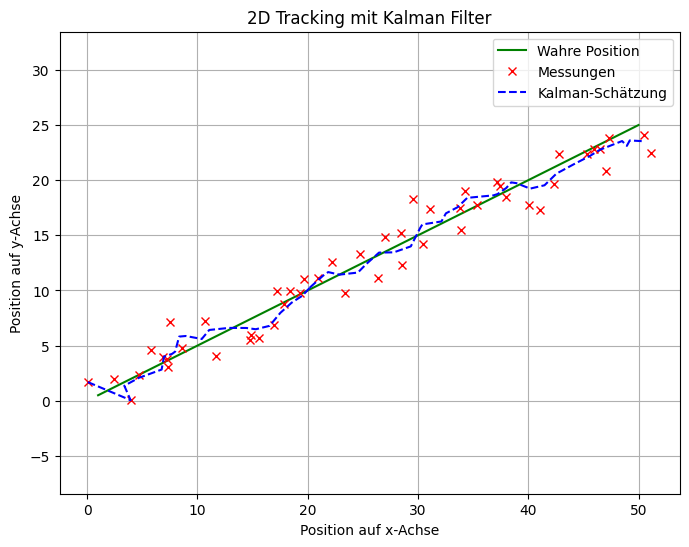

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simuliere Objektbewegung in 2D mit konstanter Geschwindigkeit
dt = 1.0  # Zeitintervall
N = 50    # Anzahl der Zeitschritte

# Wahre Bewegung
true_pos = []
x = np.array([[0], [0], [1], [0.5]])  # [x, y, vx, vy]
for _ in range(N):
    x = np.dot(np.array([[1, 0, dt, 0],
                         [0, 1, 0, dt],
                         [0, 0, 1, 0],
                         [0, 0, 0, 1]]), x)
    true_pos.append(x[:2, 0])

true_pos = np.array(true_pos)

# Simuliere verrauschte Messungen
noise_std = 1.5
measurements = true_pos + np.random.randn(*true_pos.shape) * noise_std

# Kalman-Filter Initialisierung
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0 ],
              [0, 0, 0, 1 ]])  # Systemdynamik
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])   # Messmatrix

Q = np.eye(4) * 0.01            # Prozessrauschen
R = np.eye(2) * noise_std**2    # Messrauschen

x_est = np.array([[0], [0], [0], [0]])  # Anfangszustand
P = np.eye(4) * 500                    # Anfangskovarianz

estimates = []

for z in measurements:
    # Vorhersage
    x_pred = A @ x_est
    P_pred = A @ P @ A.T + Q

    # Messung z
    z = z.reshape(2, 1)

    # Innovation
    y = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Update
    x_est = x_pred + K @ y
    P = (np.eye(4) - K @ H) @ P_pred

    estimates.append(x_est[:2, 0])

estimates = np.array(estimates)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(true_pos[:, 0], true_pos[:, 1], 'g-', label='Wahre Position')
plt.plot(measurements[:, 0], measurements[:, 1], 'rx', label='Messungen')
plt.plot(estimates[:, 0], estimates[:, 1], 'b--', label='Kalman-Schätzung')
plt.legend()
plt.title('2D Tracking mit Kalman Filter')
plt.xlabel('Position auf x-Achse')
plt.ylabel('Position auf y-Achse')
plt.grid(True)
plt.axis('equal')
plt.show()

# Code Example 2: Particle Filter with 2D-Position $(x, y)$

Ergebnis:
- Du bewegst ein Objekt mit z. B. roter Farbe vor der Kamera.
- Das Skript erkennt es beim ersten Frame (mittig) und verfolgt es über die Zeit.
- Die blauen Kreise sind die Schätzung.
- Die grünen Punkte sind die Partikel, die die möglichen Objektpositionen darstellen.

In [4]:
pip install opencv-python numpy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import numpy as np

# Einstellungen
n_particles = 200
frame_width, frame_height = 640, 480

# Initialisiere Partikel (Positionen gleichmäßig zufällig verteilt)
particles = np.column_stack((
    np.random.uniform(0, frame_width, n_particles),
    np.random.uniform(0, frame_height, n_particles)
))
weights = np.ones(n_particles) / n_particles  # Anfangs gleichverteilt

def resample(particles, weights):
    indices = np.random.choice(len(particles), size=len(particles), p=weights)
    return particles[indices]

def predict(particles, std=15):
    # Zufällige Bewegung hinzufügen
    noise = np.random.normal(0, std, particles.shape)
    particles += noise
    particles = np.clip(particles, [0, 0], [frame_width-1, frame_height-1])
    return particles

def compute_weights(particles, frame_hsv, target_hsv, hsv_thresh=20):
    d = np.linalg.norm(frame_hsv[particles[:, 1].astype(int), particles[:, 0].astype(int)] - target_hsv, axis=1)
    weights = np.exp(-(d**2) / (2 * hsv_thresh**2))
    weights += 1e-10  # damit keine Nullgewichte entstehen
    return weights / np.sum(weights)

# Starte Webcam oder Video
cap = cv2.VideoCapture(0)
cv2.namedWindow("Tracking")

# Nimm zuerst Ziel-Farbe auf (beim ersten Frame)
target_hsv = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (frame_width, frame_height))
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    if target_hsv is None:
        # Zielobjekt wählen mit Maus oder hier festlegen
        cx, cy = frame_width // 2, frame_height // 2
        target_hsv = hsv[cy, cx]
        print(f"Target HSV: {target_hsv}")

    # Vorhersage: zufällige Bewegung
    particles = predict(particles)

    # Gewichtung basierend auf Ähnlichkeit der Farben
    weights = compute_weights(particles, hsv, target_hsv)

    # Resampling
    particles = resample(particles, weights)

    # Schätzung = gewichtetes Mittel
    estimated_pos = np.average(particles, axis=0, weights=weights)

    # Zeichne Partikel
    for x, y in particles.astype(np.int32):
        cv2.circle(frame, (x, y), 1, (0, 255, 0), -1)

    # Zeichne Schätzung
    cv2.circle(frame, tuple(estimated_pos.astype(int)), 10, (255, 0, 0), 2)

    cv2.imshow("Tracking", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # ESC zum Beenden
        break

cap.release()
cv2.destroyAllWindows()

# Code Example 3: Particle Filter with 2D-Position $(x, y)$ and velocity $(v_x, v_y)$

In [ ]:
import numpy as np
import cv2

n_particles = 300
frame_width, frame_height = 640, 480
dt = 1.0  # Zeitintervall

# Zustand: [x, y, vx, vy]
particles = np.zeros((n_particles, 4))
particles[:, 0] = np.random.uniform(0, frame_width, n_particles)  # x
particles[:, 1] = np.random.uniform(0, frame_height, n_particles)  # y
particles[:, 2:] = np.random.normal(0, 2, (n_particles, 2))  # vx, vy

weights = np.ones(n_particles) / n_particles

def predict(particles, std_pos=10, std_vel=2):
    # Bewegungsgleichung: x = x + v * dt + noise
    noise_pos = np.random.normal(0, std_pos, (n_particles, 2))
    noise_vel = np.random.normal(0, std_vel, (n_particles, 2))
    
    particles[:, 0] += particles[:, 2] * dt + noise_pos[:, 0]
    particles[:, 1] += particles[:, 3] * dt + noise_pos[:, 1]
    particles[:, 2] += noise_vel[:, 0]
    particles[:, 3] += noise_vel[:, 1]

    particles[:, 0] = np.clip(particles[:, 0], 0, frame_width - 1)
    particles[:, 1] = np.clip(particles[:, 1], 0, frame_height - 1)
    return particles

def resample(particles, weights):
    indices = np.random.choice(n_particles, size=n_particles, p=weights)
    return particles[indices]

def compute_weights(particles, frame_hsv, target_hsv, hsv_thresh=20):
    x = particles[:, 0].astype(np.int32)
    y = particles[:, 1].astype(np.int32)
    hsv_vals = frame_hsv[y, x]
    d = np.linalg.norm(hsv_vals - target_hsv, axis=1)
    weights = np.exp(-(d**2) / (2 * hsv_thresh**2))
    return weights / (np.sum(weights) + 1e-10)

# Video starten
cap = cv2.VideoCapture(0)
target_hsv = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (frame_width, frame_height))
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    if target_hsv is None:
        # Zielfarbe (z. B. in Bildmitte)
        cx, cy = frame_width // 2, frame_height // 2
        target_hsv = hsv[cy, cx]
        print(f"Target HSV: {target_hsv}")

    # Vorhersage
    particles = predict(particles)

    # Gewichtung
    weights = compute_weights(particles, hsv, target_hsv)

    # Resampling
    particles = resample(particles, weights)

    # Zustandsschätzung
    pos = np.average(particles[:, :2], axis=0, weights=weights)

    # Zeichnen
    for x, y in particles[:, :2].astype(int):
        cv2.circle(frame, (x, y), 1, (0, 255, 0), -1)
    cv2.circle(frame, tuple(pos.astype(int)), 10, (255, 0, 0), 2)

    cv2.imshow("Tracking mit Geschwindigkeit", frame)
    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

Target HSV: [ 9 85 30]


ValueError: probabilities do not sum to 1

: 

# Explanation of Code Examples 2 & 3

**Code Example 2**
- only takes position $(x,y)$ as input
- no underlying motion model, random movement expected
- bad tracking for fast movements

**Code Example 3**
- takes position $(x,y)$ and velocity $(v_x, v_y)$ as input
- physical motion model which is based on inertia (Trägheit)  
    $$x = x + v * dt + noise$$ 
- better tracking for movements with inertia or better tracking if the object is covered for short periods of time

**easy explanation**

- Im ersten Filter springt das Modell ständig unvorhersehbar. Es “weiß” nicht, dass sich die Kugel mit konstanter Geschwindigkeit bewegt. Es muss sich nur auf die Farbe verlassen.
- Im zweiten Filter kennt das Modell zusätzlich die Geschwindigkeit und kann vorhersagen, wo sich das Objekt in der nächsten Sekunde befindet – selbst wenn die Kugel kurz verdeckt ist.

**Warum das wichtig ist:**
- Wenn du Bewegung und Dynamik realistisch modellieren willst, brauchst du mehr als nur die aktuelle Position.
- Durch Hinzufügen von Geschwindigkeit (vx, vy) wird der Filter robuster gegen Aussetzer in den Messdaten und reagiert flüssiger.

# Code Example 4: Kalman Filter - Mouse Tracker

 Was passiert hier?
- Du bewegst die Maus über das Fenster → das ist die “Messung”.
- Der Kalman-Filter glättet die Bewegung und sagt Positionen voraus, z. B. bei Verlust der Messung.
- Die grüne Kugel zeigt die gefilterte Position.

In [ ]:
import cv2
import numpy as np

# Kalman-Filter initialisieren
kf = cv2.KalmanFilter(4, 2)  # 4 Zustände, 2 Messgrößen

# Zustandsübergangsmatrix A
kf.transitionMatrix = np.array([[1, 0, 1, 0],
                                [0, 1, 0, 1],
                                [0, 0, 1, 0],
                                [0, 0, 0, 1]], np.float32)

# Messmatrix H
kf.measurementMatrix = np.eye(2, 4, dtype=np.float32)

# Kovarianzmatrizen
kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03
kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 0.5

# Anfangszustand (optional)
kf.statePre = np.array([[0], [0], [0], [0]], np.float32)

# Leeres Bild erzeugen
frame = np.zeros((600, 800, 3), dtype=np.uint8)
predicted = (0, 0)

def mouse_move(event, x, y, flags, param):
    global predicted
    if event == cv2.EVENT_MOUSEMOVE:
        measured = np.array([[np.float32(x)], [np.float32(y)]])
        kf.correct(measured)  # Messung einbeziehen
        prediction = kf.predict()
        predicted = (int(prediction[0]), int(prediction[1]))

cv2.namedWindow("Kalman Tracker")
cv2.setMouseCallback("Kalman Tracker", mouse_move)

while True:
    vis = frame.copy()
    # Aktuelle Vorhersage anzeigen
    cv2.circle(vis, predicted, 15, (0, 255, 0), -1)
    cv2.imshow("Kalman Tracker", vis)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cv2.destroyAllWindows()

/var/folders/hd/slgdh0b93wn1l64brhh4dkf40000gp/T/ipykernel_20665/198335618.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted = (int(prediction[0]), int(prediction[1]))


: 

# Code Example 5.1: Kalman Filter - Camera Tracker (red objects)

**Ziel:** 

Wir verfolgen ein farbiges Objekt (z. B. ein roter Ball) mit einer Kamera oder Webcam.
Die Farbe liefert die Messung, und der Kalman-Filter glättet die Bewegung und kann selbst bei kurzzeitigem Verlust (z. B. Verdeckung) weiterverfolgen.

**Was passiert hier?**

- Die Webcam erkennt rote Objekte über HSV-Farbfilter.
- Die gemessene Position (rote Kugel) wird mit dem Kalman-Filter verfolgt.
- Die Vorhersage wird als grüne Kugel angezeigt – sie bleibt auch sichtbar, wenn das Objekt kurz verdeckt ist.


**Varianten & Erweiterungen**

- Tracking anderer Farben (Blau, Grün etc.)
- Verfolgung mehrerer Objekte
- Vergleich mit Particle Filter (kann ich dir gerne zeigen!)

In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Code for tracking a red object
import cv2
import numpy as np

# Kalman Filter initialisieren
kf = cv2.KalmanFilter(4, 2)
kf.transitionMatrix = np.array([[1, 0, 1, 0],
                                [0, 1, 0, 1],
                                [0, 0, 1, 0],
                                [0, 0, 0, 1]], np.float32)
kf.measurementMatrix = np.eye(2, 4, dtype=np.float32)
kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03
kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 0.5
kf.statePre = np.array([[0], [0], [0], [0]], dtype=np.float32)

# Kamera starten (0 = erste Webcam)
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Bild glätten und in HSV umwandeln
    blurred = cv2.GaussianBlur(frame, (11, 11), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    # Farbmaske für ROT (zwei Bereiche in HSV notwendig!)
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([179, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = cv2.bitwise_or(mask1, mask2)

    # Konturen finden
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    center = None

    if contours:
        # Größte Kontur nehmen
        c = max(contours, key=cv2.contourArea)
        ((x, y), radius) = cv2.minEnclosingCircle(c)
        M = cv2.moments(c)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            center = (cx, cy)

            # Kalman-Filter mit Messung aktualisieren
            meas = np.array([[np.float32(cx)], [np.float32(cy)]])
            kf.correct(meas)

            # Kreis an Messposition
            cv2.circle(frame, center, int(radius), (0, 0, 255), 2)

    # Vorhersage des Kalman-Filters
    pred = kf.predict()
    pred_pt = (int(pred[0]), int(pred[1]))

    # Vorhersage zeichnen
    cv2.circle(frame, pred_pt, 10, (0, 255, 0), -1)
    cv2.putText(frame, "Prediction", (pred_pt[0]+10, pred_pt[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    # Anzeige
    cv2.imshow("Kalman Object Tracking", frame)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

/var/folders/hd/slgdh0b93wn1l64brhh4dkf40000gp/T/ipykernel_13976/2143756527.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_pt = (int(pred[0]), int(pred[1]))


KeyboardInterrupt: 

# Code Example 5.2: Kalman Filter - Camera Tracker (black objects)

In [44]:
# Code for tracking a black object 
import cv2
import numpy as np

# Kalman Filter initialisieren
kf = cv2.KalmanFilter(4, 2)
kf.transitionMatrix = np.array([[1, 0, 1, 0],
                                [0, 1, 0, 1],
                                [0, 0, 1, 0],
                                [0, 0, 0, 1]], np.float32)
kf.measurementMatrix = np.eye(2, 4, dtype=np.float32)
kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03
kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 0.5
kf.statePre = np.array([[0], [0], [0], [0]], dtype=np.float32)

# Kamera starten (0 = erste Webcam)
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Bild glätten und in HSV umwandeln
    blurred = cv2.GaussianBlur(frame, (11, 11), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    # Schwarz
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 255, 50])
    mask = cv2.inRange(hsv, lower_black, upper_black)

    # Alternative Farben:
    # Grün
    # lower_green = np.array([40, 70, 70])
    # upper_green = np.array([80, 255, 255])
    # mask = cv2.inRange(hsv, lower_green, upper_green)

    # Blau
    # lower_blue = np.array([100, 150, 0])
    # upper_blue = np.array([140, 255, 255])
    # mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Konturen finden
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    center = None

    if contours:
        c = max(contours, key=cv2.contourArea)
        ((x, y), radius) = cv2.minEnclosingCircle(c)
        M = cv2.moments(c)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            center = (cx, cy)

            # Kalman-Filter mit Messung aktualisieren
            meas = np.array([[np.float32(cx)], [np.float32(cy)]])
            kf.correct(meas)

            # Messpunkt (rot)
            cv2.circle(frame, center, int(radius), (0, 0, 255), 2)

    # Vorhersage zeichnen (grün)
    pred = kf.predict()
    pred_pt = (int(pred[0]), int(pred[1]))
    cv2.circle(frame, pred_pt, 10, (0, 255, 0), -1)
    cv2.putText(frame, "Prediction", (pred_pt[0]+10, pred_pt[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    # Anzeige
    cv2.imshow("Kalman Object Tracking", frame)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

/var/folders/hd/slgdh0b93wn1l64brhh4dkf40000gp/T/ipykernel_20665/1819244665.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_pt = (int(pred[0]), int(pred[1]))


KeyboardInterrupt: 